# 25 DMOs -> fatigue

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

In [27]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=125,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [5]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [7]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
dmo_data = dmo_data.mean(axis=2)

In [15]:
dmo_data = dmo_data.flatten(start_dim=1, end_dim=2)
dmo_labels = dmo_labels.flatten(start_dim=1, end_dim=2)
dmo_labels = dmo_labels[:, -1]

In [ ]:
dmo_data = dmo_data.unsqueeze(dim=1)


In [24]:
dmo_labels = dmo_labels.unsqueeze(dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=2)
dmo_labels.shape

torch.Size([280, 1, 1])

In [25]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data, dmo_labels, batch_size=16, transforms=transforms)

In [28]:
model = DMOLSTM(config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    #training_dl,
    device,
    verbose=True,
)

trainer.train_loop()
prediction, actual = trainer.test_loop()


Testing loss: 0.117177645675838


In [29]:
print(prediction)
print(actual)

[tensor([[0.3541]]), tensor([[0.3731]]), tensor([[0.6694]]), tensor([[0.7428]]), tensor([[0.5664]]), tensor([[-0.0001]]), tensor([[0.1923]]), tensor([[0.2829]]), tensor([[0.4518]]), tensor([[0.2145]]), tensor([[0.2933]]), tensor([[0.3862]]), tensor([[0.0105]]), tensor([[0.3834]]), tensor([[0.2462]]), tensor([[0.4360]]), tensor([[0.2114]]), tensor([[0.3894]]), tensor([[0.7220]]), tensor([[0.2250]]), tensor([[0.2333]]), tensor([[0.5939]]), tensor([[0.4939]]), tensor([[0.5949]]), tensor([[0.4002]]), tensor([[0.4025]]), tensor([[0.3991]]), tensor([[0.0348]]), tensor([[0.5037]]), tensor([[0.4707]]), tensor([[0.2518]]), tensor([[0.8860]]), tensor([[0.5899]]), tensor([[0.6889]]), tensor([[0.8473]]), tensor([[0.3654]]), tensor([[0.7664]]), tensor([[0.6217]]), tensor([[0.2295]]), tensor([[0.6789]]), tensor([[0.2290]]), tensor([[0.5683]]), tensor([[0.4585]]), tensor([[0.5289]]), tensor([[0.0506]]), tensor([[0.0328]]), tensor([[0.4709]]), tensor([[0.6267]]), tensor([[0.5278]]), tensor([[0.3340]])

All metrics: {'accuracy': 0.30357142857142855, 'Mean Squared Error': 0.09657033532857895, 'Mean Absolute Error': 0.23387113213539124, 'R^2': -0.8113317489624023}


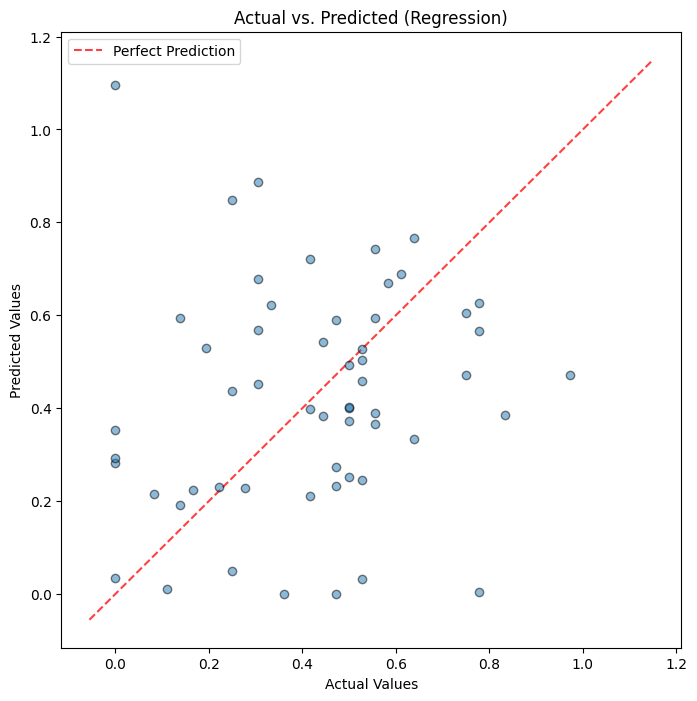

In [30]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
